#GEOG 5543 Final: Predicting Modern Locations from Historical Plat Maps Using OCR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajalonpeterson/ajalonpeterson.github.io/blob/main/plat-maps-files/plat-maps-notebook.ipynb)

> **Run this in Colab.** This notebook needs a GPU runtime for the OCR step (`Runtime` -> `Change runtime type` -> `GPU`) and no local install or GIS software license.


The notebook is separated into 4 main sections:

1. Uploading Scanned PDF of Historical Plat Image with Minimal Preprocessing
2. Extracting Feature Geometry & Prepping for OCR
3. OCR (Easy-OCR)
4. Predicting and Visualizing Modern Spatial Proximity

Refer to README for more information

## Pipeline overview

```
Scanned Plat PDF
      |
      v
Grayscale + Adaptive Threshold        (binary ink mask)
      |
      v
Connected-Components Filter + Close   (denoise, connect linework)
      |
      v
Line Segment Detection + Border Filter (candidate street lines)
      |
      v
Buffered Street Corridors             (mask for OCR)
      |
      v
EasyOCR at 0/90/-90 + Confidence Rank (street name candidates)
      |
      v
OSMnx Street Match + DBSCAN Cluster   (candidate modern area)
      |
      v
Bounding Box -> Reverse Geocode -> GeoTIFF export
```


## Setup

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [23]:
!apt-get update
!apt-get install -y poppler-utils
!pip install osmnx geopandas shapely pdf2image easyocr opencv-python shapely pandas numpy matplotlib geopy folium

import requests
from collections import defaultdict
import numpy as np
import pandas as pd
import cv2
import easyocr
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from shapely.geometry import (
    Point,
    LineString,
    Polygon,
    MultiPolygon,
    box,
)
from shapely.ops import unary_union
import geopandas as gpd
import osmnx as ox
from sklearn.cluster import DBSCAN
import folium
import rasterio
from rasterio.transform import from_bounds
from geopy.geocoders import Nominatim
from geopy.distance import geodesic


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,539 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,849 kB]
Fetched 12.4 MB in 3s (3,787 kB/s)
Reading package li

### Environment info (for reproducibility)

Recorded so that if this notebook fails for a recruiter re-running it later, it's easy to tell
whether an upstream package update is the cause rather than the pipeline itself. For stricter
reproducibility, pin the `!pip install` line above to the versions printed below.


In [ ]:
import importlib.metadata as _metadata

_packages = [
    "torch", "opencv-python", "easyocr", "osmnx", "geopandas", "shapely",
    "pdf2image", "scikit-learn", "folium", "rasterio", "geopy", "pandas", "numpy",
]

for pkg in _packages:
    try:
        print(f"{pkg}: {_metadata.version(pkg)}")
    except _metadata.PackageNotFoundError:
        print(f"{pkg}: not found")


# Part 1: Uploading Scanned PDF of Historical Plat Image with Minimal Preprocessing

Download the scanned plat PDF and convert the first page to a PNG at 300 DPI, which is sufficient resolution for the OCR steps later. Minimal preprocessing here on purpose - anything more aggressive at this stage risks destroying faint linework before it's even been detected.

**Reproducibility note:** if the county server is down or blocks the request, the cell below falls back to a bundled copy at `data/ramsey_19.pdf`. Make sure that file is committed alongside this notebook.

In [ ]:
import os

url = "https://rcxnet.co.ramsey.mn.us/GISLibrary/ScannedSurveyRecords/SubdivisionPlats/SurveyPlats/19.pdf"
pdf_path = "ramsey_19.pdf"
local_fallback_path = "data/ramsey_19.pdf"  # bundled copy, used if the county server is unreachable

try:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    with open(pdf_path, "wb") as f:
        f.write(response.content)
    print(f"Downloaded plat PDF from {url}")
except requests.exceptions.RequestException as e:
    if os.path.exists(local_fallback_path):
        print(f"Download failed ({e}); using bundled copy at {local_fallback_path}")
        pdf_path = local_fallback_path
    else:
        raise RuntimeError(
            "Could not download the plat PDF and no bundled fallback was found at "
            f"'{local_fallback_path}'. Add a copy of the plat PDF there, or fix the URL/network."
        ) from e

# DPI 300 is sufficient for our purposes
img = convert_from_path(pdf_path, dpi=300)[0]
img.save("original_plat.png")

plt.figure(figsize=(8,10))
plt.imshow(img)
plt.axis("off")
plt.title("Original Plat Image")
plt.show()


Convert to grayscale. A basic step, but it's what the masks in Part 2 are built on.

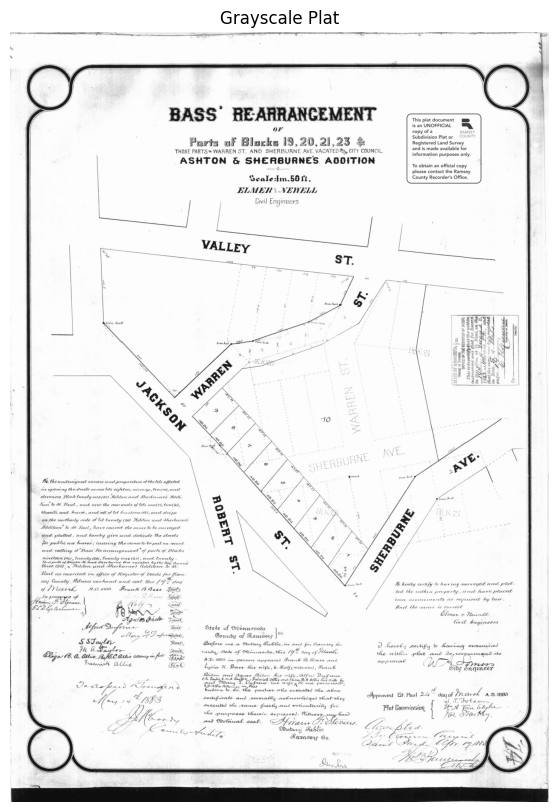

In [4]:
img_cv = cv2.imread("original_plat.png")
gray_scale = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
H, W = gray_scale.shape  # used throughout the geometry steps below

plt.figure(figsize=(8,10))
plt.imshow(gray_scale, cmap="gray")
plt.axis("off")
plt.title("Grayscale Plat")
plt.show()

# Part 2: Extracting Feature Geometry & Prepping for OCR

Disclaimer: We will be using line segement detection primarily for creating our OCR mask. Not all of these components were ultimately used to the extent that they could have been (i.e. vectorizing our lines and applying them to a modern day map) due to the very large scope of this project and the preprocessing needed to extract a fully connected and helpful product. However, this is a beneficial and I believe somewhat common technique in this field, so we will keep this even though it is somewhat unecessary for THIS plat.

### 2.1 Binary ink mask

An adaptive threshold turns the grayscale scan into a binary ink mask, which the line segment detector below needs as its input. [Adaptive threshold docs](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html).

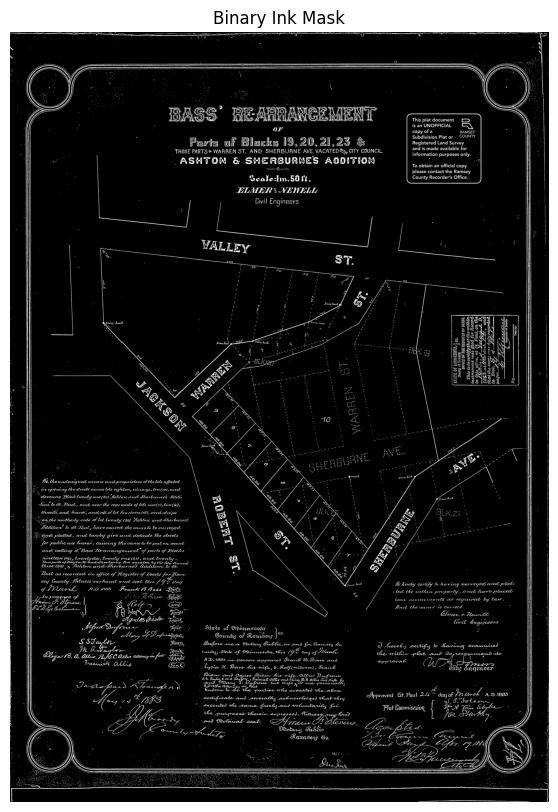

In [5]:
# adaptive threshold docs: https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
binary_mask = cv2.adaptiveThreshold(
    gray_scale,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=35,  # must be odd
    C=15
)

plt.figure(figsize=(8, 10))
plt.imshow(binary_mask, cmap="gray")
plt.axis("off")
plt.title("Binary Ink Mask")
plt.show()

### 2.2 Filtering out noise

`connectedComponentsWithStats` groups the binary mask into connected white regions. Keeping only components above a minimum area removes small specks of noise before line detection runs. [Docs](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html).

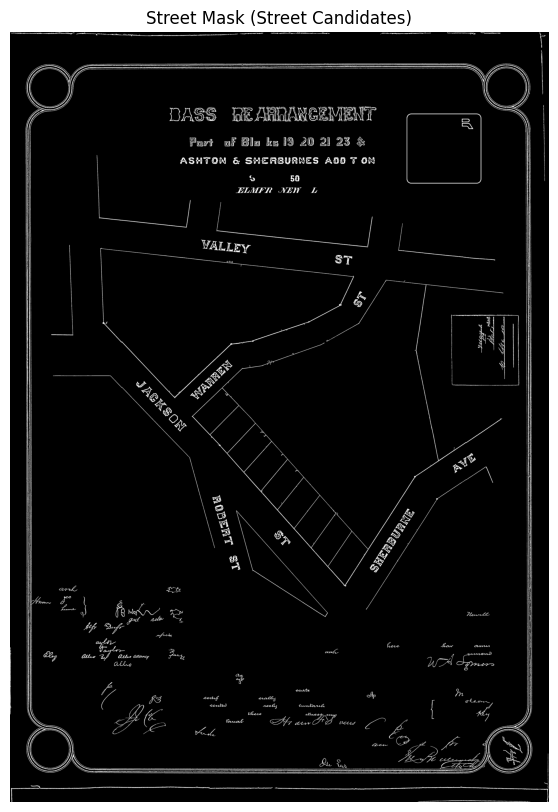

In [6]:
# docs: https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    binary_mask, connectivity=8
)

Minimum_area = 1500  # keep only large white segments, filters out noise
street_mask = np.zeros_like(binary_mask)

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= Minimum_area:
        street_mask[labels == i] = 255

plt.figure(figsize=(8, 10))
plt.imshow(street_mask, cmap="gray")
plt.axis("off")
plt.title("Street Mask (Street Candidates)")
plt.show()

### 2.3 Closing small gaps

A morphological close bridges small gaps in the linework that can otherwise break a single street into multiple disconnected segments. [Docs](https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_morphological_ops/py_morphological_ops.html).

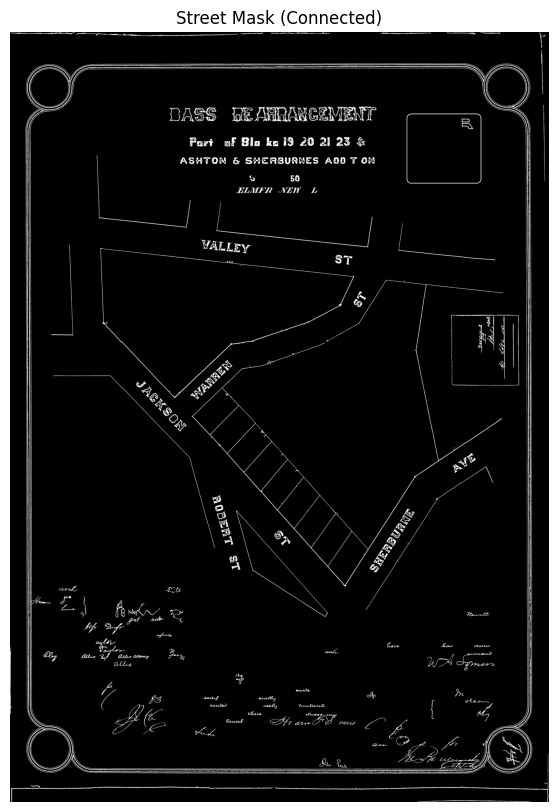

In [7]:
# docs: https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_morphological_ops/py_morphological_ops.html
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
street_mask = cv2.morphologyEx(street_mask, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(8, 10))
plt.imshow(street_mask, cmap="gray")
plt.axis("off")
plt.title("Street Mask (Connected)")
plt.show()

### 2.4 Detecting line segments

OpenCV's line segment detector runs on the refined mask, and detections are filtered by length to drop short, spurious segments. The page border and legend box are still picked up here - handled next.

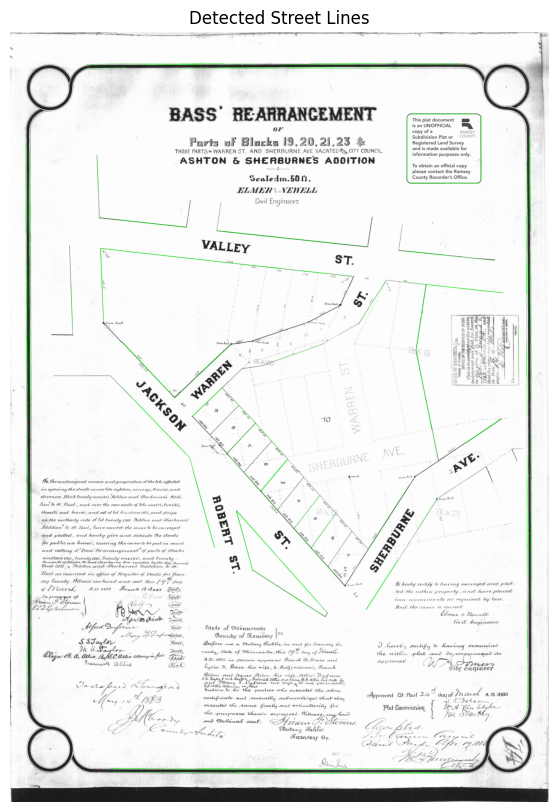

In [8]:
lsd = cv2.createLineSegmentDetector(0)
lines, _, _, _ = lsd.detect(street_mask)

raw_street_lines = []
if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = map(int, l[0])
        if np.hypot(x2 - x1, y2 - y1) > 400:  # length filter
            raw_street_lines.append((x1, y1, x2, y2))
len(raw_street_lines)

vis = cv2.cvtColor(gray_scale, cv2.COLOR_GRAY2BGR)
for x1, y1, x2, y2 in raw_street_lines:
    cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Street Lines")
plt.show()

### 2.5 Removing border artifacts

Rather than fine-tuning the detector itself, a simple margin-based filter drops any line whose midpoint falls within 9% of the page edge. That percentage was chosen to be small enough to keep real street lines near the edge, while still cutting the page border and legend box - which is what the raw-to-filtered count below demonstrates. Note: the Ramsey County stamp still survives this filter, which is a known limitation flagged in the Part 2 disclaimer above.

Raw Street Lines: 161
After Filtering Border: 68


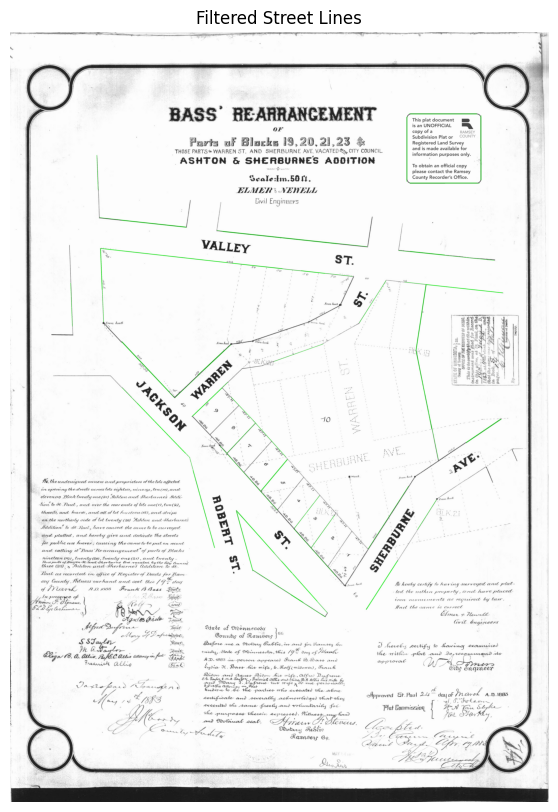

In [10]:
Img_margin = int(0.09 * min(H, W))  # 9% margin, chosen to generalize across plats

def near_edge(l):
    x1, y1, x2, y2 = l
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    return (
        cx < Img_margin or cx > W - Img_margin or
        cy < Img_margin or cy > H - Img_margin
    )

filtered_street_lines = [
    l for l in raw_street_lines if not near_edge(l)
]

print("Raw Street Lines:", len(raw_street_lines))
print("After Filtering Border:", len(filtered_street_lines))

vis = cv2.cvtColor(gray_scale, cv2.COLOR_GRAY2RGB)
for x1, y1, x2, y2 in filtered_street_lines:
    cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8,10))
plt.imshow(vis)
plt.axis("off")
plt.title("Filtered Street Lines")
plt.show()

### 2.6 Building street corridors from a buffer

This is the core idea of the whole pipeline. Rather than trying to classify which detected lines are actually streets, every line gets buffered by a fixed pixel radius and the buffers are unioned together - producing a corridor around anything line-shaped on the page. The buffer distance (`buffer_pixels=220`) was hand-tuned for this plat and would likely need adjusting for others.

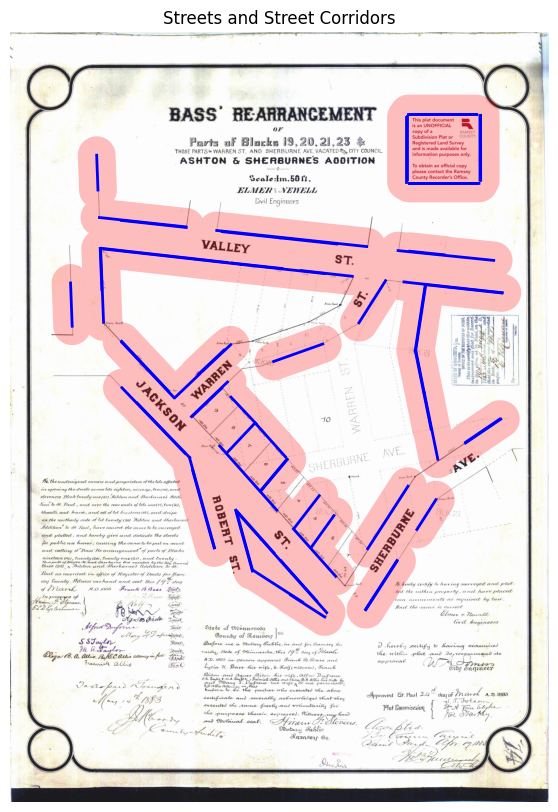

In [11]:
def create_street_corridors(
    street_lines,
    base_image,
    buffer_pixels=220,  # may need adjusting depending on plat size
    figsize=(8, 10),
):
    """Buffer each detected line into a corridor polygon and union them together.

    This is the core idea of the whole masking step: rather than classifying which
    detected lines are actually streets, every line gets a fixed-radius buffer
    (``buffer_pixels``) and the buffers are merged into one shape. Anything
    line-shaped on the page ends up inside a corridor, which is what later gets
    used to mask the image down to just the areas OCR should look at.

    Parameters
    ----------
    street_lines : list[tuple[int, int, int, int]]
        Line segments as (x1, y1, x2, y2) pixel coordinates.
    base_image : array-like
        Image to draw the corridors over, for visual QC.
    buffer_pixels : int
        Buffer radius in pixels. Hand-tuned for this plat's scan resolution;
        likely needs adjusting for plats scanned at a different DPI or scale.
    figsize : tuple[int, int]
        Matplotlib figure size for the QC plot.

    Returns
    -------
    shapely.geometry.Polygon | shapely.geometry.MultiPolygon
        The unioned corridor geometry.
    """
    linestrings = [
        LineString([(x1, y1), (x2, y2)])
        for (x1, y1, x2, y2) in street_lines
    ]

    buffers = [ls.buffer(buffer_pixels) for ls in linestrings]
    corridors = unary_union(buffers)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(base_image, cmap="gray")

    def draw_polygon(poly, color="red", alpha=0.25):
        x, y = poly.exterior.xy
        ax.fill(x, y, color=color, alpha=alpha, linewidth=0)

    if isinstance(corridors, Polygon):
        draw_polygon(corridors)
    elif isinstance(corridors, MultiPolygon):
        for poly in corridors.geoms:
            draw_polygon(poly)

    for x1, y1, x2, y2 in street_lines:
        ax.plot([x1, x2], [y1, y2], color="blue", linewidth=2)

    ax.set_title("Streets and Street Corridors")
    ax.axis("off")
    plt.show()

    return corridors

street_corridors_geom = create_street_corridors(
    filtered_street_lines,
    base_image=img,
    buffer_pixels=220
)

### 2.7 Masking the image to the street corridors

The corridor polygons get rasterized into a binary mask, then applied to the grayscale image so only pixels inside a corridor survive.

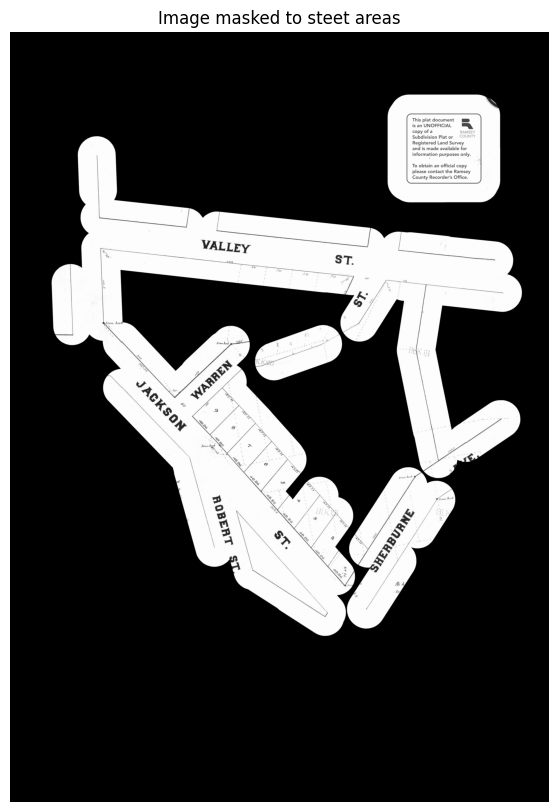

In [12]:
H, W = gray_scale.shape
street_area_mask = np.zeros((H, W), dtype=np.uint8)

def rasterize_polygon_to_mask(polygon, target_mask):
    coords = np.array(polygon.exterior.coords, dtype=np.int32)
    cv2.fillPoly(target_mask, [coords], 255)

if street_corridors_geom.geom_type == "Polygon":
    rasterize_polygon_to_mask(street_corridors_geom, street_area_mask)
elif street_corridors_geom.geom_type == "MultiPolygon":
    for poly in street_corridors_geom.geoms:
        rasterize_polygon_to_mask(poly, street_area_mask)

street_only_image = cv2.bitwise_and(
    gray_scale,
    gray_scale,
    mask=street_area_mask
)

plt.figure(figsize=(8, 10))
plt.imshow(street_only_image, cmap="gray")
plt.axis("off")
plt.title("Image masked to steet areas")
plt.show()

### 2.8 Preparing the final OCR input

Flip the masked-out area back to white so the result reads as normal black-text-on-white - this is what actually gets passed into OCR, and it's what cuts down cleanup work later by eliminating everything outside the street corridors before OCR ever sees it.

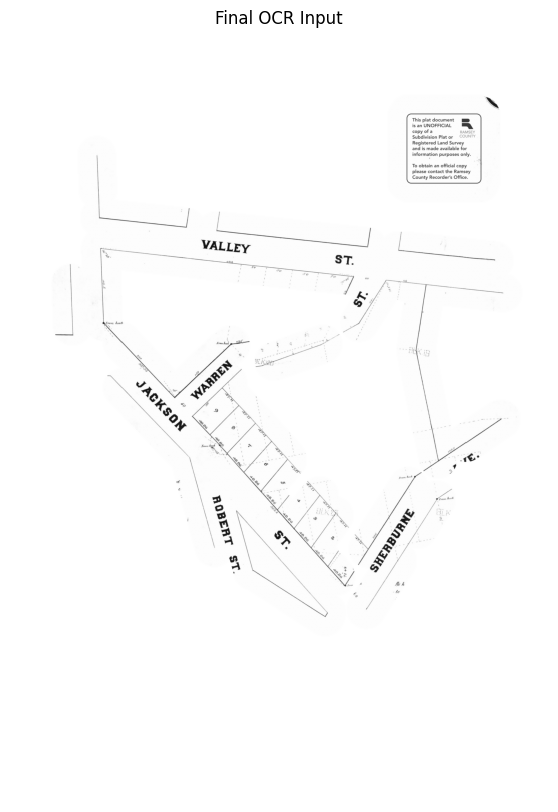

In [13]:
ocr_img = gray_scale.copy()
ocr_img[street_only_image == 0] = 255  # back to black text on white, minimizes OCR cleanup later

plt.figure(figsize=(8,10))
plt.imshow(ocr_img, cmap="gray")
plt.axis("off")
plt.title("Final OCR Input")
plt.show()

# Part 3: OCR (Easy-OCR)

### 3.1 OCR for maximum recall

EasyOCR is run for maximum recall rather than precision - constraints get applied to the results afterward instead of at this stage, since placing constraints on the OCR call itself tended to produce misspellings. Even on the masked image, some street names (the ones running diagonally, like Jackson and Robert) weren't legible right-side-up, so OCR runs three times - at 0°, 90°, and -90° - and every hit from all three passes is kept. The bounding-box coordinates are kept in the results even though only the text and confidence end up being used downstream; they'd be useful for snapping labels back to street lines in a future version, but that would require an un-rotate step this notebook doesn't implement.

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

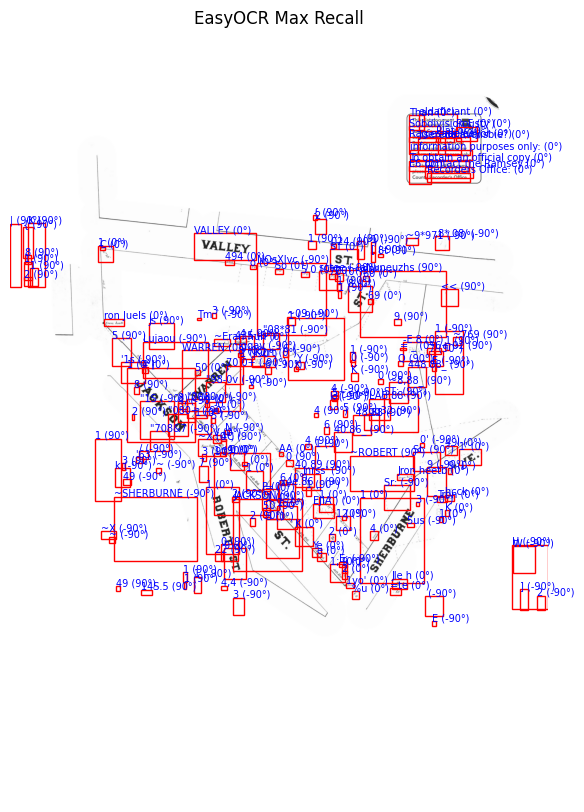

In [15]:
reader = easyocr.Reader(
    ['en'],
    gpu=True,
    recog_network='english_g2'
)

if len(ocr_img.shape) == 2:
    ocr_rgb = cv2.cvtColor(ocr_img, cv2.COLOR_GRAY2RGB)
else:
    ocr_rgb = ocr_img.copy()

H, W = ocr_rgb.shape[:2]

def rotate_image(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))

angles = [0, 90, -90]
rows = []

for angle in angles:
    rotated = rotate_image(ocr_rgb, angle)

    results = reader.readtext(
        rotated,
        detail=1,
        paragraph=False,
        text_threshold=0.1,
        low_text=0.1,
        link_threshold=0.1,
        mag_ratio=1.5,
    )

    for bbox, text, conf in results:
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]

        # left/top/width/height/cx/cy kept for potential future use snapping text to street lines,
        # which would need an UNROTATE step to be usable
        rows.append({
            "text": text.strip(),
            "conf": float(conf),
            "angle": angle,
            "left": int(min(xs)),
            "top": int(min(ys)),
            "width": int(max(xs) - min(xs)),
            "height": int(max(ys) - min(ys)),
            "cx": float(np.mean(xs)),
            "cy": float(np.mean(ys)),
        })

ocr_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(ocr_rgb)

for _, r in ocr_df.iterrows():
    ax.add_patch(
        patches.Rectangle(
            (r.left, r.top),
            r.width,
            r.height,
            linewidth=1,
            edgecolor="red",
            facecolor="none"
        )
    )
    ax.text(
        r.left,
        max(0, r.top - 2),
        f"{r.text} ({r.angle}°)",
        color="blue",
        fontsize=7
    )

ax.axis("off")
ax.set_title("EasyOCR Max Recall")
plt.show()

### 3.2 Cleaning the OCR output

The result above is noisy - duplicate detections, partial words, and stray characters caught in the linework. Instead of hard filtering rules, each detection gets a weighted rank score: OCR confidence (highest priority), the ratio of uppercase characters (street labels on the plat are consistently all-caps), and text size (lowest priority). Everything above a rank and length threshold survives, and duplicates from the three OCR passes get collapsed down to the highest-confidence version.

In [16]:
df = ocr_df.copy()

# street names are all uppercase, ratio used for ranking below
df["upper_ratio"] = df["text"].apply(
    lambda s: sum(c.isupper() for c in s) / max(len(s), 1)
)

df["text_clean"] = (
    df["text"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z]", "", regex=True)
)

df["len"] = df["text_clean"].str.len()

# ranked score: OCR confidence (highest priority), uppercase ratio, then text size
df["rank_score"] = (
    2.0 * df["conf"] +
    1.5 * df["upper_ratio"] +
    0.5 * np.log1p(df["width"] * df["height"])
)

df_filtered = df[
    (df["conf"] > 0.7) &
    (df["rank_score"] > 9) &
    (df["len"] >= 5)
].copy()

df_final = (
    df_filtered
    .sort_values("conf", ascending=False)
    .drop_duplicates(subset="text_clean")
    .rename(columns={"text_clean": "street_text"})
    .copy()
)

street_names = (
    df_final["street_text"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

df_final[[
    "street_text",
    "conf",
    "upper_ratio",
    "len",
    "rank_score",
    "angle"
]].sort_values("rank_score", ascending=False)

,street_text,conf,upper_ratio,len,rank_score,angle
140,JACKSON,0.999524,1.000000,7,10.206293,90
62,WARREN,0.993464,1.000000,6,10.028397,0
13,VALLEY,0.994912,1.000000,6,9.661673,0
203,SHERBURNE,0.760537,0.900000,9,9.617174,-90
135,ROBERT,0.758154,0.857143,6,9.118013,90


# Part 4: Predicting and Visualizing Modern Spatial Proximity

I am not entirely convinced that this is the best approach, since it likely needs to be customized for other plats. However, many other strategies were tried and failed, including various geocoders and numerical spatial operations. The benefit of this approach is that I did not need to OCR street suffixes and append them accordingly, which took a lot of time. It simply requires the street names and attempts to identify the modern day locations. Another reason why this approach was successful was because signficiant reconstruction has occured from the time the historical plat existed, and not all of my target streets were present, and identifying intersections that still exist also posed excessive challenges.

### 4.1 Matching streets and clustering endpoints

The target place (`Saint Paul, Ramsey County, Minnesota, USA`) is the one manual input in this notebook. OSMnx pulls the current street network for that area, filtered down to edges whose names match the cleaned OCR street list. Every matched street's endpoints are extracted and clustered with DBSCAN based on real-world proximity in meters, rather than relying on modern intersections - which, a century of reconstruction later, often don't exist in the same place. The cluster with the most distinct matched streets is kept, outlier points are trimmed by distance from the cluster centroid, and what remains is wrapped in a padded bounding box.

In [17]:
place = "Saint Paul, Ramsey County, Minnesota, USA"  # only manual input in this notebook
street_names = street_names  # from OCR cleaning above

eps = 200            # DBSCAN proximity to endpoint, in meters
min_samples = 3      # endpoints needed to form a cluster

DIST_PCT = 0.2        # keep closest 20% of endpoints to centroid
PAD = 40               # padding around final box, in meters

G = ox.graph_from_place(place, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False)

edges["name_clean"] = edges["name"].astype(str).str.upper()

matched_edges = edges[
    edges["name_clean"].apply(lambda n: any(s in n for s in street_names))
].copy()

edges_proj = matched_edges.to_crs(epsg=26915)

def line_endpoints(geom):
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return [Point(coords[0]), Point(coords[-1])]
    elif geom.geom_type == "MultiLineString":
        pts = []
        for part in geom.geoms:
            coords = list(part.coords)
            pts.append(Point(coords[0]))
            pts.append(Point(coords[-1]))
        return pts
    return []

rows = []
for _, r in edges_proj.iterrows():
    for p in line_endpoints(r.geometry):
        rows.append({
            "street": r["name_clean"],
            "geometry": p
        })

endpoints = gpd.GeoDataFrame(rows, crs=edges_proj.crs)

endpoints["x"] = endpoints.geometry.x.round(2)
endpoints["y"] = endpoints.geometry.y.round(2)
endpoints = endpoints.drop_duplicates(subset=["street", "x", "y"]).copy()

coords = np.column_stack([endpoints.geometry.x, endpoints.geometry.y])

db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
endpoints["cluster"] = db.labels_

clusters = endpoints[endpoints["cluster"] != -1]

# pick the cluster with the most distinct matched streets, tie-break by smaller area
cluster_stats = []
for cl, grp in clusters.groupby("cluster"):
    distinct_streets = grp["street"].nunique()
    pts = np.column_stack([grp.geometry.x, grp.geometry.y])
    minx, miny = pts.min(axis=0)
    maxx, maxy = pts.max(axis=0)
    area = (maxx - minx) * (maxy - miny)
    cluster_stats.append((cl, distinct_streets, area))

cluster_stats.sort(key=lambda t: (-t[1], t[2]))
best_cluster = cluster_stats[0][0]

best = clusters[clusters["cluster"] == best_cluster].copy()

# trim long tails - the cluster had a bias toward Jackson/Robert St which warped the box
centroid = best.geometry.unary_union.centroid
best["dist"] = best.geometry.distance(centroid)

cutoff = best["dist"].quantile(DIST_PCT)
core = best[best["dist"] <= cutoff]

minx, miny, maxx, maxy = core.total_bounds
bbox_proj = box(minx - PAD, miny - PAD, maxx + PAD, maxy + PAD)

bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_proj], crs=edges_proj.crs)
bbox_ll = bbox_gdf.to_crs(epsg=4326)
minx_ll, miny_ll, maxx_ll, maxy_ll = bbox_ll.total_bounds

/tmp/ipython-input-1681337572.py:84: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = best.geometry.unary_union.centroid


### 4.2 Visual QC on a map

Plot the matched streets, the trimmed endpoint cluster, and the resulting bounding box to sanity-check the result.

In [18]:
m = folium.Map(
    location=[(miny_ll + maxy_ll)/2, (minx_ll + maxx_ll)/2],
    zoom_start=15,
    tiles="cartodbpositron"
)

edges_ll = matched_edges.to_crs(epsg=4326)
for _, r in edges_ll.iterrows():
    folium.GeoJson(
        r.geometry,
        style_function=lambda x: {"color": "#444444", "weight": 2}
    ).add_to(m)

core_ll = core.to_crs(epsg=4326)
for _, r in core_ll.iterrows():
    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],
        radius=5,
        color="red",
        fill=True,
        fill_opacity=0.9,
        tooltip=r["street"]
    ).add_to(m)

folium.Rectangle(
    bounds=[[miny_ll, minx_ll], [maxy_ll, maxx_ll]],
    color="red",
    weight=3,
    fill=False
).add_to(m)

m

### 4.3 Reverse geocoding the predicted location

The bounding box from 4.1 is a shape, not an answer to "where is this today." Reverse
geocoding the box's centroid through Nominatim turns it into a human-readable modern
address, which is what actually answers the notebook's title question. A marker for
this point is added to the map above.


In [ ]:
geocoder = Nominatim(user_agent="plat-ocr-notebook-ajalonpeterson")

predicted_lat = (miny_ll + maxy_ll) / 2
predicted_lon = (minx_ll + maxx_ll) / 2

# Nominatim's usage policy caps free requests at 1/sec; a single lookup here is well within that.
location = geocoder.reverse((predicted_lat, predicted_lon), exactly_one=True, timeout=10)
predicted_address = location.address if location else "No address found for this point"

print("Predicted centroid (lat, lon):", (predicted_lat, predicted_lon))
print("Reverse-geocoded present-day location:")
print(predicted_address)

folium.Marker(
    location=[predicted_lat, predicted_lon],
    popup=predicted_address,
    icon=folium.Icon(color="green", icon="flag"),
).add_to(m)

m


### 4.4 Validating against a known reference point (optional)

If the plat's actual historical location is known (e.g. from county records), set
`REFERENCE_LATLON` below to check how far the predicted centroid landed from it. This
turns "it looks right on the map" into a measured error in meters. Leave it as `None`
to skip.


In [ ]:
# Set to a known ground-truth (lat, lon) for this plat to quantify prediction error.
# e.g. REFERENCE_LATLON = (44.9537, -93.0900)
REFERENCE_LATLON = None

if REFERENCE_LATLON is not None:
    predicted_point = (predicted_lat, predicted_lon)
    offset_meters = geodesic(REFERENCE_LATLON, predicted_point).meters
    print(f"Distance from known reference point: {offset_meters:.1f} m")
else:
    print(
        "REFERENCE_LATLON not set - skipping quantitative accuracy check. "
        "Set it to a known ground-truth coordinate for this plat to measure prediction error."
    )


### 4.5 Exporting a GeoTIFF (optional)

This is included mainly for demonstration - the exported raster doesn't encode much beyond the bounding box itself. A meaningful next step, if line detection generalized better across plats, would be to bake the extracted street geometry into this output instead.

In [24]:
# demonstration only - a next step, if line detection had worked better on a more relevant plat,
# would be to incorporate the extracted geometry into this GeoTIFF
PIXEL_SIZE = 20  # meters per pixel

minx, miny, maxx, maxy = bbox_proj.bounds

width = int((maxx - minx) / PIXEL_SIZE)
height = int((maxy - miny) / PIXEL_SIZE)

transform = from_bounds(minx, miny, maxx, maxy, width, height)

data = np.ones((height, width), dtype=np.uint8)

with rasterio.open(
    "street_convergence_bbox.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=data.dtype,
    crs="EPSG:26915",
    transform=transform,
) as dst:
    dst.write(data, 1)

print("GeoTIFF exported: street_convergence_bbox.tif")

GeoTIFF exported: street_convergence_bbox.tif


## Results & limitations

- The pipeline takes a historical plat (Ramsey County plat 19) down to a bounded, reverse-geocoded
  present-day location in Saint Paul, MN using only OCR'd street names matched against the current
  OSM street network -- no manual geocoding or street-suffix cleanup required.
- Known limitations: the corridor buffer (`buffer_pixels=220`) and border margin (9%) are hand-tuned
  to this plat's scan resolution and would need re-tuning for others; the county stamp survives the
  border filter (flagged in the Part 2 disclaimer); and the GeoTIFF export (4.5) only encodes the
  bounding box, not the extracted street geometry.
- Next steps: derive the buffer/margin parameters from image DPI instead of fixed pixel constants so
  they generalize across scans, snap OCR text back to the detected line segments (bounding boxes are
  already retained for this in 3.1), and bake the matched street geometry into the GeoTIFF instead of
  a flat bounding box.
